In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 📊 Stress Prediction Model - ML Service Notebook

## Notebook Purpose
This notebook represents the **core of predictive analytics** in the EDA (Event-Driven Architecture). Its main objective is to **develop and evaluate machine learning models for predicting user stress levels** based on fused data from:

1. **Garmin wearable devices** (stress_score, body_battery, heart rate, respiration)
2. **Environmental sensors** (temperature, humidity, CO2, TVOC)

## Position in the Architecture
The notebook operates in the **`/services/data_analysis/`** service and uses data that has been:
- Collected from edge devices via MQTT
- Transferred to Mosquitto broker
- Bridged to Kafka through `mqtt_kafka_bridge`
- Consumed and processed by `kafka_consumer`
- Enriched with Garmin data from the `backend` service
- Fused together to create `fusion_df.csv`

## Main Workflow

### 1. Data Preprocessing (Cells 1-23)
- Loads the fused dataset with second-level duplicates
- Aggregates data to **minute-level** granularity to reduce redundancy
- Handles missing values with backward fill
- Exports clean dataset to `ordered.csv`

### 2. Regression Analysis (Cells 24-49)
- **Target**: stress_score (continuous value)
- **Features**: 7 variables (body_battery, hr, respiration_rate, temperature, humidity, CO2, TVOC)
- Uses **LazyRegressor** to automatically compare 20+ algorithms
- **Best result**: HistGradientBoostingRegressor (R²=0.75, RMSE=9.12)
- In-depth analyses: feature importance, residuals, metrics by model family

### 3. Classification Analysis (Cells 50-65)
- **Target**: binary stress (low <45, high ≥45)
- Compares classifiers to identify high/low stress states
- Metrics: accuracy, precision, recall, F1-score, ROC curves
- Visual evaluation through confusion matrices

## Impact on Services
This notebook will feed:
- The ML service in production for real-time inferences
- Stress monitoring dashboards
- Alert system for high-stress conditions
- Work environment optimization based on environmental correlations

## 🔑 Key Insights
**Discovered Correlations:**
- Heart rate (hr) and body_battery are strongly correlated with stress
- Environmental factors (CO2, TVOC) have moderate correlations
- The model achieves 75% predictive accuracy (R²=0.75)

**Next Steps:**
1. Deploy the best model (HistGradientBoostingRegressor) to production
2. Integrate predictions into the real-time alerting system
3. Optimize environmental parameters based on stress correlations

Import DataFrame

In [2]:
df = pd.read_csv('/home/claudiagalantino/eda-architecture/services/data_analysis/fusion_df_1.csv')

### DataFrame Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13790 entries, 0 to 13789
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp_local      13790 non-null  object 
 1   garmin_id            13790 non-null  object 
 2   room                 13790 non-null  object 
 3   hr                   11237 non-null  float64
 4   stress_score         5158 non-null   float64
 5   body_battery         5158 non-null   float64
 6   activity_type        1018 non-null   object 
 7   intensity            1018 non-null   object 
 8   steps                1018 non-null   float64
 9   temperature_DHT22_C  13790 non-null  float64
 10  humidity_DHT22_%     13790 non-null  float64
 11  CO2_ppm              13790 non-null  float64
 12  TVOC_ppb             13790 non-null  float64
 13  respiration_rate     1342 non-null   float64
dtypes: float64(9), object(5)
memory usage: 1.5+ MB


In [4]:
df["activity_type"].unique()

array([nan, 'SEDENTARY'], dtype=object)

In [5]:
df["garmin_id"].unique()

array(['66c2c60b-769f-4d63-b470-a3ae5c6ed251',
       '8d738deb-db44-405e-ac6a-ce73135eb434',
       'add44d45-b0dd-44be-b700-16738b6f7f10'], dtype=object)

In [6]:
df["room"].unique()

array(['home', 'library', 'lab'], dtype=object)

In [7]:
df["intensity"].unique()

array([nan, 'SEDENTARY'], dtype=object)

In [8]:
df["steps"].unique()

array([nan,  0.])

In [9]:
df.isna().sum()

timestamp_local            0
garmin_id                  0
room                       0
hr                      2553
stress_score            8632
body_battery            8632
activity_type          12772
intensity              12772
steps                  12772
temperature_DHT22_C        0
humidity_DHT22_%           0
CO2_ppm                    0
TVOC_ppb                   0
respiration_rate       12448
dtype: int64

Backward fill dei valori NaN

In [10]:
df["stress_score"] = df["stress_score"].bfill()

In [11]:
df["body_battery"] = df["body_battery"].bfill()

In [12]:
df["hr"] = df["hr"].bfill()

In [13]:
df["respiration_rate"] = df["respiration_rate"].bfill()


In [14]:
df.isna().sum()

timestamp_local            0
garmin_id                  0
room                       0
hr                         0
stress_score               3
body_battery               3
activity_type          12772
intensity              12772
steps                  12772
temperature_DHT22_C        0
humidity_DHT22_%           0
CO2_ppm                    0
TVOC_ppb                   0
respiration_rate        1171
dtype: int64

Ordina DataFrame per garmin_id e poi per timestamp

In [15]:
# Convert timestamp to datetime and round to minute
df['timestamp_local'] = pd.to_datetime(df['timestamp_local'])
df['timestamp_minute'] = df['timestamp_local'].dt.floor('T')  # Round to minute

# Group by garmin_id and minute, aggregating with mean for numeric columns
agg_dict = {
    'stress_score': 'mean',
    'body_battery': 'mean',
    'hr': 'mean',
    'respiration_rate': 'mean',
    'temperature_DHT22_C': 'mean',
    'humidity_DHT22_%': 'mean',
    'CO2_ppm': 'mean',
    'TVOC_ppb': 'mean',
    'room': 'first',  # Keep first value for categorical
    'activity_type': 'first',
    'intensity': 'first',
    'steps': 'sum'  # Sum steps within the same minute
}

df = df.groupby(['garmin_id', 'timestamp_minute']).agg(agg_dict).reset_index()
df = df.rename(columns={'timestamp_minute': 'timestamp_local'})
df = df.sort_values(['garmin_id', 'timestamp_local']).reset_index(drop=True)

/tmp/ipykernel_1008419/4249013817.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df['timestamp_minute'] = df['timestamp_local'].dt.floor('T')  # Round to minute


In [16]:
df.to_csv('/home/claudiagalantino/eda-architecture/services/data_analysis/ordered.csv', index=False)

In [17]:
#df.to_csv('/home/claudiagalantino/eda-architecture/services/data_analysis/shifted.csv', index=False)

Creiamo training dataframe
Definiamo TARGET, TRAIN_FEATURES 

In [18]:
TARGET = "stress_score"
FEATURES = ["body_battery", "hr", "respiration_rate", "temperature_DHT22_C", "humidity_DHT22_%", "CO2_ppm", "TVOC_ppb"]
#FEATURES = ["hr", "respiration_rate", "temperature_DHT22_C", "humidity_DHT22_%", "CO2_ppm", "TVOC_ppb"]
#FEATURES = ["respiration_rate", "temperature_DHT22_C", "humidity_DHT22_%", "CO2_ppm", "TVOC_ppb"]



In [19]:
X = df[FEATURES].copy()
y = df[TARGET].copy() # original

### Shift del target
In questo modo alleniamo il modello a predire lo stress futuro dati i valori correnti.

In [20]:
y = y.shift(periods=5) # prevedo i 5 minuti successivi

Remove NaN values 

In [21]:
X.fillna(X.mean(), inplace = True)

In [22]:
y.fillna(y.mean(), inplace = True)

In [23]:
X

,body_battery,hr,respiration_rate,temperature_DHT22_C,humidity_DHT22_%,CO2_ppm,TVOC_ppb
0,35.000000,68.0,14.720000,19.4,52.6,402.0,0.0
1,35.000000,69.0,14.720000,19.4,52.6,402.0,0.0
2,35.000000,71.0,14.720000,19.4,52.6,402.0,0.0
3,35.333333,68.0,14.720000,19.4,52.6,402.0,0.0
4,36.000000,70.0,14.720000,19.4,52.6,402.0,0.0
...,...,...,...,...,...,...,...
6610,17.000000,75.0,16.145973,19.7,49.9,400.0,0.0
6611,17.000000,75.0,16.145973,19.7,49.9,400.0,0.0
6612,43.000000,78.0,16.145973,19.7,49.9,400.0,0.0
6613,74.000000,71.0,16.145973,19.7,49.9,400.0,0.0


In [24]:
print(X.isna().sum())

body_battery           0
hr                     0
respiration_rate       0
temperature_DHT22_C    0
humidity_DHT22_%       0
CO2_ppm                0
TVOC_ppb               0
dtype: int64


In [25]:
print(y.isna().sum())

0


### Correlazione tra features

In [26]:
#df_corr = df[FEATURES + [TARGET]].corr()

In [27]:
# import matplotlib.pyplot as plt
# import numpy as np

# fig, ax = plt.subplots(figsize=(10, 10))
# cax     = ax.matshow(df_corr,cmap='coolwarm', vmin=-1, vmax=1)

# fig.colorbar(cax)
# ticks = np.arange(0,len(df_corr.columns),1)
# ax.set_xticks(ticks)

# ax.set_xticklabels(df_corr.columns)
# plt.xticks(rotation = 90)

# ax.set_yticklabels(df_corr.columns)
# ax.set_yticks(ticks)

# #---print the correlation factor---
# for i in range(df_corr.shape[1]):
#     for j in range(df_corr.shape[1]):
#         text = ax.text(j, i, round(df_corr.iloc[i][j],2),
#                        ha="center", va="center", color="w")
# plt.show()

## REGRESSION

### Analisi di Regressione

- Target: stress_score
- Features: 7 variabili (body_battery, hr, respiration_rate, temperature, humidity, CO2, TVOC)
- Utilizza LazyRegressor per confrontare automaticamente 42 algoritmi semplici

Risultato migliore: HistGradientBoostingRegressor (R²=0.75, RMSE=9.12)
- Analisi approfondite: feature importance, residuals, metriche per famiglia di modelli

In [28]:
# from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5292, 7) (1323, 7) (5292,) (1323,)


## CLASSIFICATION

In [31]:
STRESS_THRESHOLD = 45

In [32]:
y_classification = (y >= STRESS_THRESHOLD).astype(int)

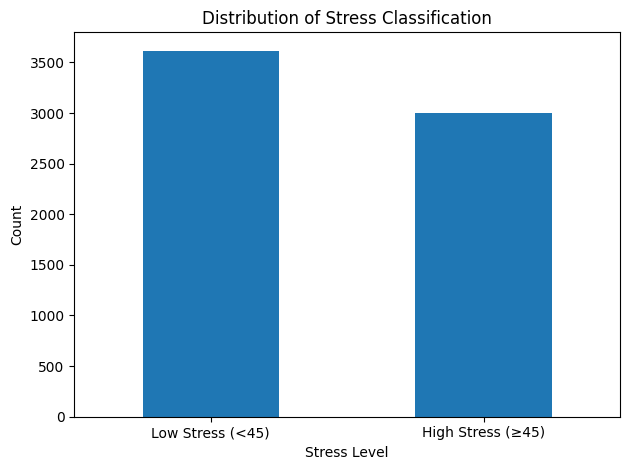

In [33]:
import matplotlib.pyplot as plt

y_classification.value_counts().plot(kind='bar')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.title('Distribution of Stress Classification')
plt.xticks([0, 1], [f'Low Stress (<{STRESS_THRESHOLD})', f'High Stress (≥{STRESS_THRESHOLD})'], rotation=0)
plt.tight_layout()
plt.show()

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y_classification, test_size=0.2, random_state=42)

In [35]:
from lazypredict.Supervised import LazyClassifier

In [36]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, 
                     custom_metric = None, predictions=True)

scores, predictions = clf.fit(X_train, X_test, y_train, y_test)
scores

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2408, number of negative: 2884
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000325 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 595
[LightGBM] [Info] Number of data points in the train set: 5292, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.455026 -> initscore=-0.180382
[LightGBM] [Info] Start training from score -0.180382


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LGBMClassifier,0.78,0.78,0.78,0.78,0.31
XGBClassifier,0.77,0.77,0.77,0.77,0.17
LabelPropagation,0.77,0.76,0.76,0.77,0.72
LabelSpreading,0.77,0.76,0.76,0.77,1.28
ExtraTreesClassifier,0.77,0.76,0.76,0.76,0.31
BaggingClassifier,0.76,0.76,0.76,0.76,0.08
NuSVC,0.77,0.76,0.76,0.76,1.28
RandomForestClassifier,0.76,0.75,0.75,0.76,0.33
KNeighborsClassifier,0.75,0.75,0.75,0.75,0.02


In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

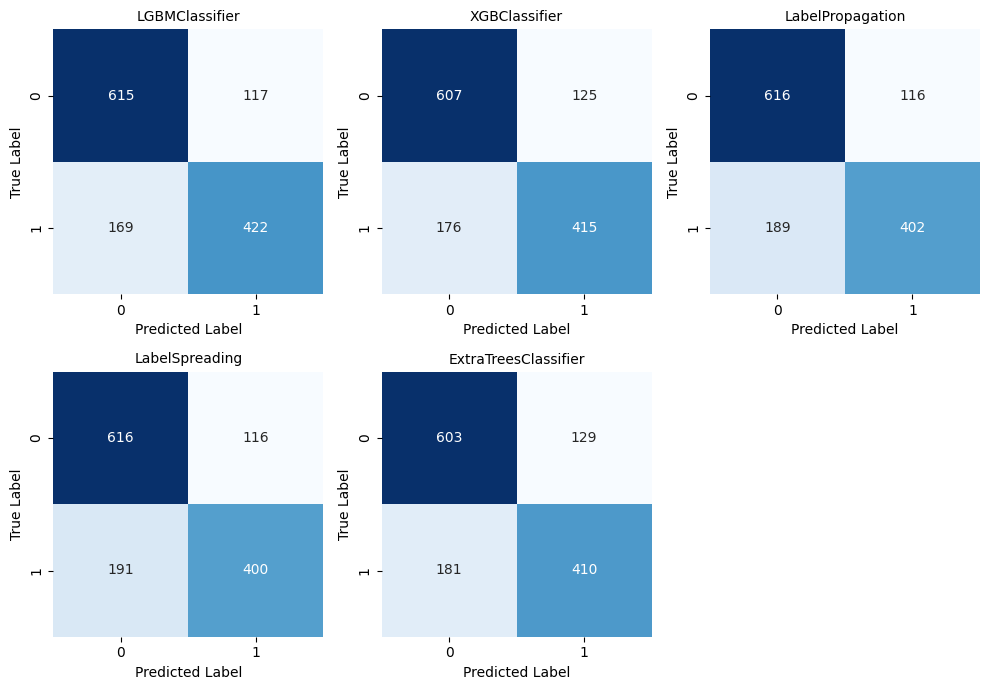

In [38]:
# Create confusion matrices for the first 5 models
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

top_5_models = scores.head(5).index.tolist()

for idx, model_name in enumerate(top_5_models):
    y_pred = predictions[model_name]
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(model_name, fontsize=10)
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

# Hide the extra subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

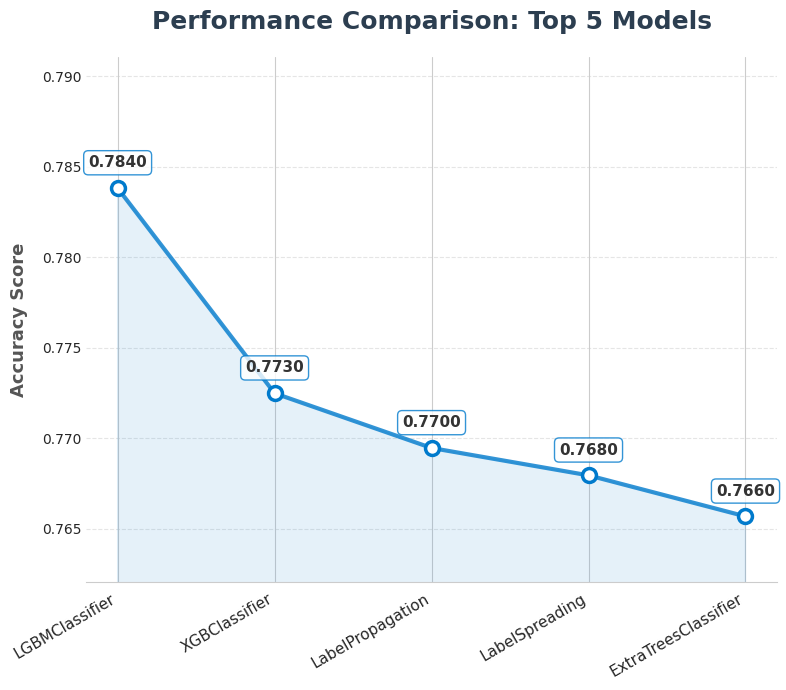


📊 Top 5 Models Accuracy (Rounded Up):
Model
LGBMClassifier         0.78
XGBClassifier          0.77
LabelPropagation       0.77
LabelSpreading         0.77
ExtraTreesClassifier   0.77
Name: Accuracy, dtype: float64


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# --- FUNZIONE PER ARROTONDAMENTO PER ECCESSO ---
def ceil_decimals(value, decimals=4):
    factor = 10 ** decimals
    return math.ceil(value * factor) / factor

# Configurazione stile base
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# --- PREPARAZIONE DATI ---
N = 5
top_N_models = scores.head(N).index.tolist()
top_scores = scores.loc[top_N_models, 'Accuracy']

# --- CREAZIONE GRAFICO ---
fig, ax = plt.subplots(figsize=(8, 7))

# Colore principale
main_color = '#007ACC' 

# 1. Linea Principale
ax.plot(range(len(top_N_models)), top_scores.values, 
        color=main_color, 
        linewidth=3, 
        linestyle='-', 
        alpha=0.8,
        zorder=2)

# 2. Area Colorata sotto la curva
ax.fill_between(range(len(top_N_models)), top_scores.values, 
                y2=min(top_scores.values) - 0.05, 
                color=main_color, 
                alpha=0.1, 
                zorder=1)

# 3. Marker Personalizzati
ax.scatter(range(len(top_N_models)), top_scores.values, 
           color='white', 
           edgecolor=main_color, 
           s=100, 
           linewidth=2.5, 
           zorder=3,
           label='Accuracy')

# --- FORMATTAZIONE E DETTAGLI ---

# Annotazioni Valori (ARROTONDATI PER ECCESSO)
for i, acc in enumerate(top_scores.values):
    # Applichiamo l'arrotondamento per eccesso a 4 cifre
    rounded_acc = ceil_decimals(acc, 3)
    
    ax.annotate(f'{rounded_acc:.4f}', 
                xy=(i, acc), 
                xytext=(0, 15), 
                textcoords='offset points',
                ha='center', 
                fontsize=11, 
                fontweight='bold',
                color='#333333',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=main_color, alpha=0.8))

# Titoli e Label
ax.set_title(f'Performance Comparison: Top {N} Models', fontsize=18, fontweight='bold', pad=20, color='#2c3e50')
ax.set_ylabel('Accuracy Score', fontsize=13, fontweight='bold', labelpad=10, color='#555555')

# Asse X
ax.set_xticks(range(len(top_N_models)))
ax.set_xticklabels(top_N_models, rotation=30, ha='right', fontsize=11)

# Asse Y Dinamico
y_min = top_scores.min()
y_max = top_scores.max()
padding = (y_max - y_min) * 0.4
ax.set_ylim([y_min - padding/2, y_max + padding])

# Pulizia finale
sns.despine(left=True, bottom=False)
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.tick_params(axis='y', which='both', length=0)

plt.tight_layout()
plt.show()

# Print accuracy scores (Arrotondati per eccesso anche qui per coerenza)
print(f"\n📊 Top {N} Models Accuracy (Rounded Up):")
print(top_scores.apply(lambda x: ceil_decimals(x, 4)))

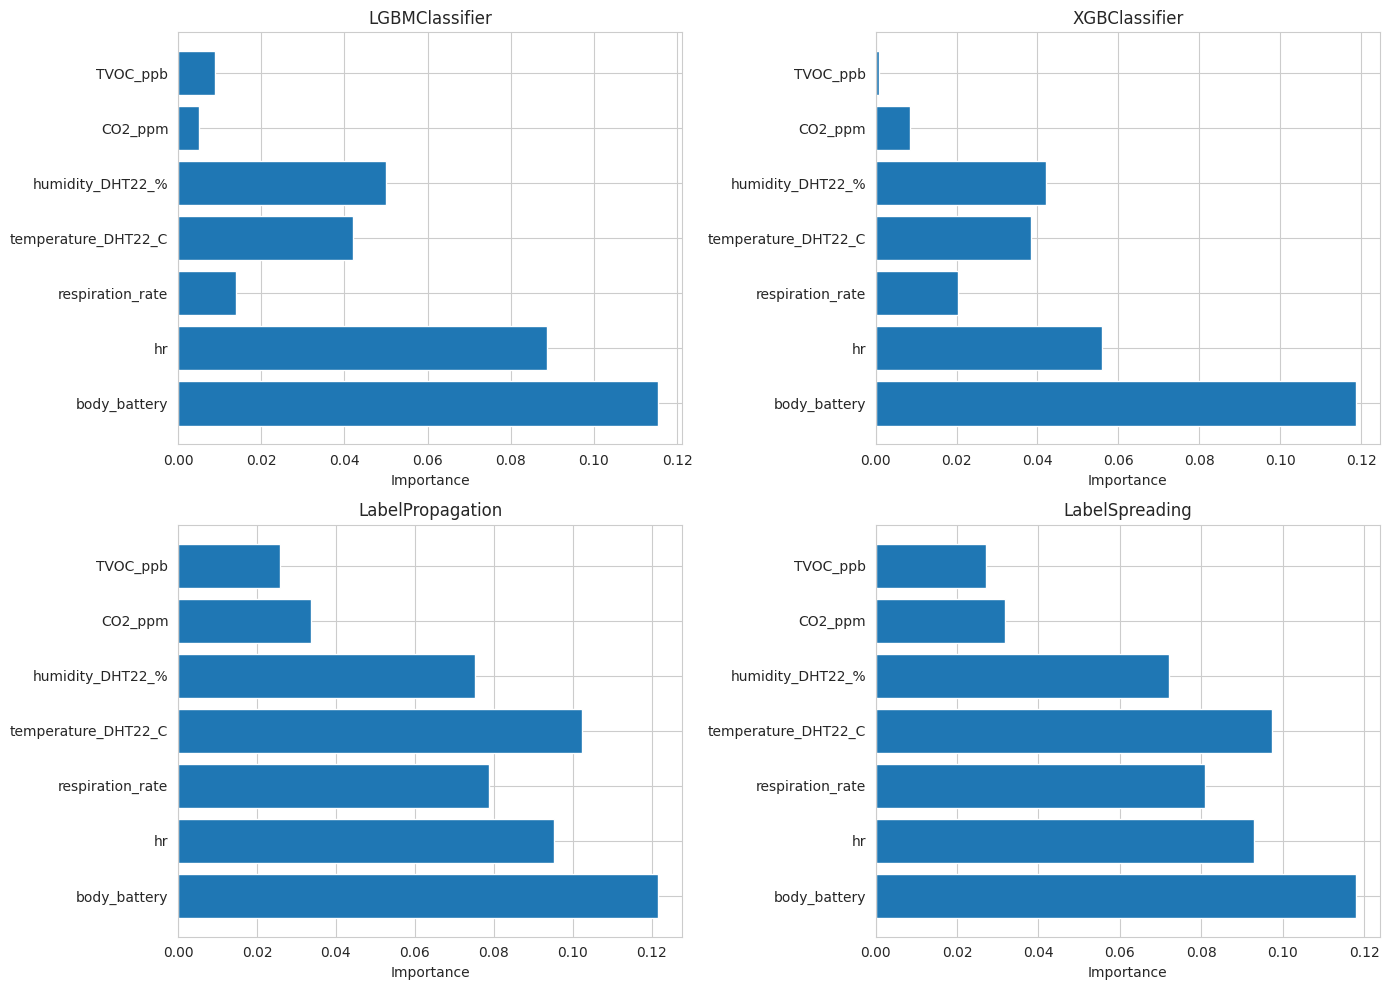

In [40]:
from sklearn.inspection import permutation_importance

N = 4

# Prendi i primi N modelli dal ranking
top_N_models = scores.head(N).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, model_name in enumerate(top_N_models):
    # Ottieni il modello addestrato da LazyClassifier
    model = clf.models[model_name]
    # Calcola la feature importance
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0])  # Use absolute values for classification
    else:
        # fallback: permutation importance
        result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
        importances = result.importances_mean

    axes[idx].barh(FEATURES, importances)
    axes[idx].set_title(model_name)
    axes[idx].set_xlabel("Importance")

# axes[4].set_visible(False)

plt.tight_layout()
plt.show()

In [41]:
# 5. ROC curves for top N models
from sklearn.metrics import roc_curve, auc

N = 5
top_N_models = scores.head(N).index.tolist()

fig, ax = plt.subplots(figsize=(10, 8))

for model_name in top_N_models:
    model = clf.models[model_name]
    
    # Get probability predictions if available
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_pred_proba = model.decision_function(X_test)
    else:
        continue
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Top 5 Classifiers')
ax.legend()
plt.tight_layout()
plt.show()

In [42]:
# 6. Precision-Recall curves
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(10, 8))

for model_name in top_N_models:
    model = clf.models[model_name]
    
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_pred_proba = model.decision_function(X_test)
    else:
        continue
    
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    
    ax.plot(recall, precision, label=f'{model_name} (AP = {avg_precision:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves - Top 5 Classifiers')
ax.legend()
plt.tight_layout()
plt.show()

In [43]:
# 9. Feature Importance and Performance by Model Family - CLASSIFICATION
from sklearn.inspection import permutation_importance

# Define model families based on common model types
model_families_clf = {
    'Tree-based': ['ExtraTreesClassifier', 'RandomForestClassifier', 'GradientBoostingClassifier', 
                   'HistGradientBoostingClassifier', 'XGBClassifier', 'LGBMClassifier', 'DecisionTreeClassifier'],
    'SVM': ['SVC', 'NuSVC', 'LinearSVC'],
    'Linear': ['LogisticRegression', 'RidgeClassifier', 'SGDClassifier', 'Perceptron', 
               'PassiveAggressiveClassifier'],
    'Ensemble': ['AdaBoostClassifier', 'BaggingClassifier'],
    'Neighbors': ['KNeighborsClassifier', 'NearestCentroid'],
    'Naive Bayes': ['GaussianNB', 'BernoulliNB'],
    'Other': ['QuadraticDiscriminantAnalysis', 'LinearDiscriminantAnalysis']
}

# Get best model from each family
best_per_family_clf = {}
for family, model_types in model_families_clf.items():
    for model_name in scores.index:
        if any(model_type in model_name for model_type in model_types):
            if family not in best_per_family_clf:
                best_per_family_clf[family] = {
                    'name': model_name,
                    'accuracy': scores.loc[model_name, 'Accuracy'],
                    'f1': scores.loc[model_name, 'F1 Score']
                }
            break

# Remove empty families
best_per_family_clf = {k: v for k, v in best_per_family_clf.items() if v}

print("Best models per family (Classification):")
for family, info in best_per_family_clf.items():
    print(f"{family}: {info['name']} (Acc = {info['accuracy']:.4f}, F1 = {info['f1']:.4f})")

# Create subplots for feature importance and performance
n_families = len(best_per_family_clf)
fig, axes = plt.subplots(1, figsize=(12, 5))

# Plot 1: Feature Importance for best model in each family
ax1 = axes
x_pos = np.arange(len(FEATURES))
width = 0.8 / n_families

for idx, (family, info) in enumerate(best_per_family_clf.items()):
    model_name = info['name']
    model = clf.models[model_name]
    
    # Get feature importance
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0])
    else:
        result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42)
        importances = result.importances_mean
    
    # Normalize importances
    importances = importances / importances.sum()
    
    offset = (idx - n_families/2) * width + width/2
    ax1.bar(x_pos + offset, importances, width, label=f'{family}', alpha=0.8)

ax1.set_ylabel('Normalized Importance')
ax1.set_title('Feature Importance by Model Family - Classification')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(FEATURES, rotation=45, ha='right')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(axis='y', alpha=0.3)


Best models per family (Classification):
Tree-based: LGBMClassifier (Acc = 0.7838, F1 = 0.7826)
SVM: NuSVC (Acc = 0.7687, F1 = 0.7638)
Linear: LogisticRegression (Acc = 0.6606, F1 = 0.6525)
Ensemble: BaggingClassifier (Acc = 0.7642, F1 = 0.7628)
Neighbors: KNeighborsClassifier (Acc = 0.7513, F1 = 0.7508)
Naive Bayes: BernoulliNB (Acc = 0.6689, F1 = 0.6694)
Other: LinearDiscriminantAnalysis (Acc = 0.6576, F1 = 0.6478)


## 🚀 Model Deployment & Export

Export the trained model, preprocessing logic, and configuration for production use in the orchestrator.


## 🎨 Comparison Visualizations

Different ways to visualize user stress comparison in the same room:

### Radar Chart 🕸️

Pattern circolare giornaliero dello stress

Identifica picchi e momenti tranquilli nella giornata

Facilita il confronto visivo tra utenti

## 🏠 Stress Behavior Across Different Rooms - Same User Analysis

Visualize how stress levels change for a single user across different rooms/locations:

 Box plot & Violin plot - Distribuzione dello stress per stanza

Heatmap - Pattern orario dello stress per stanza

In [44]:
# # 3. HEATMAP - Hour of Day vs Room (same user)
# # Crea pivot table: hours vs rooms
# user_room_data['hour'] = user_room_data['timestamp_local'].dt.hour
# pivot_stress = user_room_data.pivot_table(values='stress_score', 
#                                          index='hour', 
#                                          columns='room', 
#                                          aggfunc='mean')

# fig, ax = plt.subplots(figsize=(12, 8))
# sns.heatmap(pivot_stress, cmap='RdYlGn_r', annot=True, fmt='.1f', 
#            cbar_kws={'label': 'Avg Stress Score'}, ax=ax, 
#            linewidths=0.5, linecolor='gray')
# ax.set_title(f'🔥 Hourly Stress Pattern by Room - User {target_user}', 
#             fontsize=14, fontweight='bold')
# ax.set_xlabel('Room', fontsize=12, fontweight='bold')
# ax.set_ylabel('Hour of Day', fontsize=12, fontweight='bold')
# plt.tight_layout()
# plt.show()

# print(f"\n🗺️ Average Stress by Hour and Room - User {target_user}")
# print(pivot_stress.round(2))


Radar charts - Cicli 24-ore dello stress per ogni stanza

Bar chart - Stress medio per stanza con deviazione standard

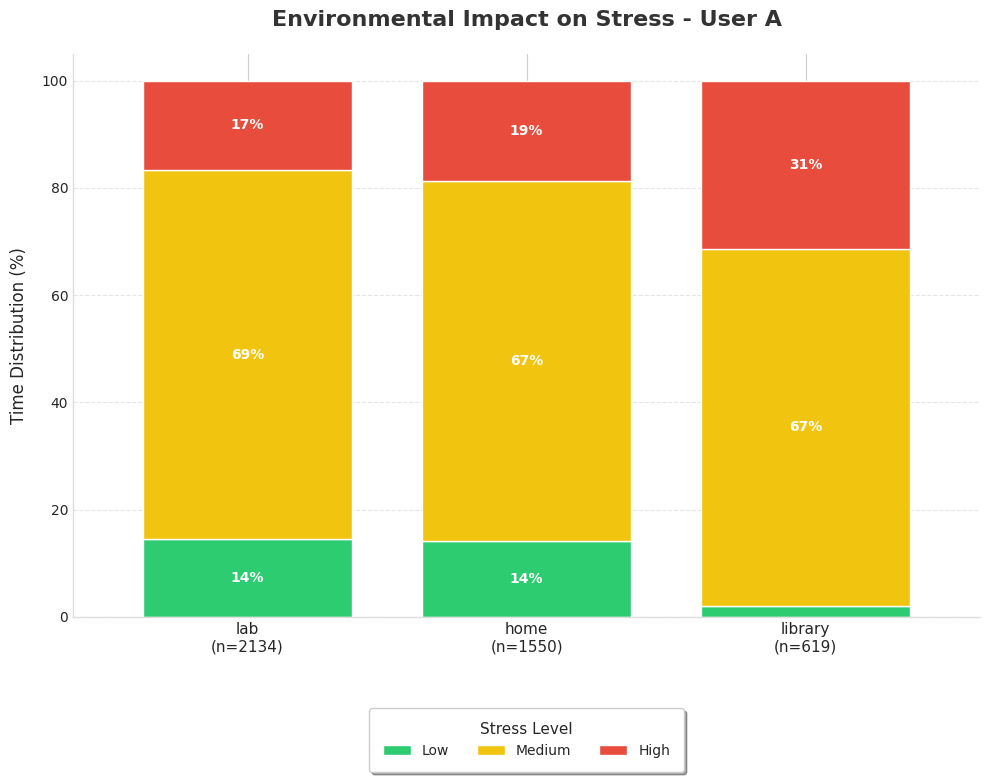

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Assicuriamoci che i timestamp siano datetime
df['timestamp_local'] = pd.to_datetime(df['timestamp_local'])
df = df.sort_values('timestamp_local')

# Classificazione
def classify_stress(score):
    if score <= 25: return 'Low'
    elif score <= 60: return 'Medium'
    else: return 'High'

# Target futuro (5 min)
horizon = pd.Timedelta(minutes=5)
df_target = df[['timestamp_local', 'garmin_id', 'stress_score']].copy()
df_target['timestamp_match'] = df_target['timestamp_local'] - horizon

df_labeled = pd.merge_asof(
    df,
    df_target[['timestamp_match', 'garmin_id', 'stress_score']],
    left_on='timestamp_local',
    right_on='timestamp_match',
    by='garmin_id',
    direction='nearest',
    tolerance=pd.Timedelta(minutes=1),
    suffixes=('', '_future')
)

df_labeled = df_labeled.dropna(subset=['stress_score_future'])
df_labeled['target_class'] = df_labeled['stress_score_future'].apply(classify_stress)

# Training
features = ['body_battery', 'hr', 'temperature_DHT22_C', 'humidity_DHT22_%', 'CO2_ppm']
X = df_labeled[features].fillna(0)
y = df_labeled['target_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

df_labeled['pred_class_5min'] = clf.predict(X)

# Ordine categorico rigoroso
class_order = ['Low', 'Medium', 'High']
df_labeled['pred_class_5min'] = pd.Categorical(df_labeled['pred_class_5min'], categories=class_order, ordered=True)

# Identifica utente target
user_room_counts = df_labeled.groupby('garmin_id')['room'].nunique()
target_user = user_room_counts.idxmax()
num_rooms = user_room_counts.max()

# Filtra dati utente
user_df = df_labeled[df_labeled['garmin_id'] == target_user].copy()

# Calcolo percentuali
stress_dist = user_df.groupby(['room', 'pred_class_5min'], observed=False).size().unstack(fill_value=0)

# --- MIGLIORAMENTO 1: Filtro Stanze Significative ---
# Escludiamo stanze dove l'utente è stato pochissimo (meno di 10 rilevazioni), 
# per evitare colonne strane con 100% basato su 1 solo dato.
total_counts = stress_dist.sum(axis=1)
valid_rooms = total_counts[total_counts > 10].index
stress_dist = stress_dist.loc[valid_rooms]
total_counts = total_counts.loc[valid_rooms] # Aggiorna i conteggi per le etichette

# Calcolo percentuali normalizzate
stress_props = stress_dist.div(stress_dist.sum(axis=1), axis=0) * 100

# --- MIGLIORAMENTO 2: Ordinamento per "Stress" ---
# Ordiniamo le barre in modo che le stanze più stressanti (più 'High') siano a destra
stress_props = stress_props.sort_values(by=['High', 'Medium'], ascending=True)

# --- PLOTTING STYLE ---
# Impostiamo uno stile pulito
plt.style.use('seaborn-v0_8-whitegrid') 
plt.figure(figsize=(10, 8))

# --- MIGLIORAMENTO 3: Colori Custom ---
# Verde (Relax), Arancio (Attenzione), Rosso (Allerta) - Colori 'Flat Design'
custom_colors = ['#2ecc71', '#f1c40f', '#e74c3c'] 

ax = stress_props.plot(
    kind='bar', 
    stacked=True, 
    color=custom_colors, 
    width=0.75, 
    edgecolor='white', # Bordo bianco tra i segmenti per pulizia
    linewidth=1,
    figsize=(10, 8),
    ax=plt.gca() # Usa l'asse corrente
)

# Titoli e Label
plt.title(f"Environmental Impact on Stress - User A", fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.ylabel("Time Distribution (%)", fontsize=12, labelpad=10)
plt.xlabel("", fontsize=12) # Rimuovo label x generica, uso i nomi delle stanze

# --- MIGLIORAMENTO 4: Etichette Asse X più ricche ---
# Aggiungiamo il numero di campioni (n) sotto il nome della stanza
labels = [f"{room}\n(n={total_counts[room]})" for room in stress_props.index]
ax.set_xticklabels(labels, rotation=0, fontsize=11)

# Legenda pulita
plt.legend(
    title="Stress Level", 
    title_fontsize='11',
    fontsize='10',
    bbox_to_anchor=(0.5, -0.15), 
    loc='upper center', 
    frameon=True,
    framealpha=1,
    shadow=True,
    borderpad=1,
    ncol=3
)

# Griglia e Bordi
plt.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')

# --- Etichette Percentuali ---
for c in ax.containers:
    # Mostriamo l'etichetta solo se il segmento è abbastanza grande (>5%) per essere leggibile
    labels = [f'{v.get_height():.0f}%' if v.get_height() > 5 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. PREPARAZIONE DATI ---
# Assicuriamoci che i timestamp siano datetime
df_labeled['timestamp_local'] = pd.to_datetime(df_labeled['timestamp_local'])

# Filtro orario generale (9-18) per l'analisi
work_hours_df = df_labeled[
    (df_labeled['timestamp_local'].dt.hour >= 9) & 
    (df_labeled['timestamp_local'].dt.hour <= 18)
].copy()

if work_hours_df.empty:
    print("Nessun dato nella fascia oraria 9-18.")
else:
    # --- 2. SELEZIONE AUTOMATICA (SMART SEARCH) ---
    
    # Contiamo gli utenti unici per ogni stanza
    room_stats = work_hours_df.groupby('room')['garmin_id'].nunique()
    
    # Teniamo solo le stanze con almeno 2 utenti
    shared_rooms = room_stats[room_stats >= 2].index.tolist()
    
    if not shared_rooms:
        print("Non ci sono stanze con almeno 2 utenti in questa fascia oraria.")
    else:
        # Tra le stanze condivise, scegliamo quella con più dati totali (righe)
        # per avere il grafico più affidabile
        best_room = work_hours_df[work_hours_df['room'].isin(shared_rooms)]['room'].value_counts().idxmax()
        
        # Ora identifichiamo i due utenti TOP in questa stanza
        room_data = work_hours_df[work_hours_df['room'] == best_room]
        top_users = room_data['garmin_id'].value_counts().head(2).index.tolist()
        
        print(f"--- ANALISI AUTOMATICA ---")
        print(f"Stanza selezionata: {best_room}")
        print(f"Utenti confrontati: {top_users[0]} vs {top_users[1]}")
        
        # --- 3. AGGREGAZIONE DATI ---
        # Filtriamo solo per la stanza e gli utenti scelti
        plot_df = room_data[room_data['garmin_id'].isin(top_users)].copy()
        
        # Estraiamo l'ora (0-23)
        plot_df['hour_int'] = plot_df['timestamp_local'].dt.hour
        
        # Media per ora e utente
        hourly_comparison = (
            plot_df.groupby(['hour_int', 'garmin_id'])['stress_score']
            .mean()
            .reset_index()
        )
        
        # --- 4. PLOTTING ---
        plt.figure(figsize=(8, 6))
        colors = ['#1f77b4', '#ff7f0e'] # Blu e Arancione

        for i, user in enumerate(top_users):
            user_curve = hourly_comparison[hourly_comparison['garmin_id'] == user].sort_values('hour_int')
            
            if user_curve.empty:
                continue
                
            # Linea
            plt.plot(
                user_curve['hour_int'], 
                user_curve['stress_score'], 
                marker='o', 
                linewidth=2.5, 
                label=f"User: {user}",
                color=colors[i]
            )
            
            # Area
            plt.fill_between(
                user_curve['hour_int'], 
                user_curve['stress_score'], 
                alpha=0.15, 
                color=colors[i]
            )

        # Decorazioni
        plt.title(f"Stress Comparison: User A vs User B\nRoom: {best_room} (9:00 AM - 6:00 PM)", fontsize=15, fontweight='bold')
        plt.xlabel("Day Time (9 AM - 6 PM)", fontsize=12)
        plt.ylabel("Average Stress Score", fontsize=12)
        plt.xticks(range(9, 19))
        plt.ylim(0, 100)
        
        # Thresholds
        plt.axhline(y=25, color='green', linestyle='--', alpha=0.3, label='Rest (<25)')
        plt.axhline(y=40, color='orange', linestyle='--', alpha=0.3, label='Low (25-59)')
        plt.axhline(y=60, color='red', linestyle='--', alpha=0.3, label='High (> 60)')

        plt.grid(True, axis='both', linestyle=':', alpha=0.6)
        plt.legend(bbox_to_anchor=(0.5, -0.45), loc='center', ncol= 1)

        plt.tight_layout()
        plt.show()

--- ANALISI AUTOMATICA ---
Stanza selezionata: lab
Utenti confrontati: 66c2c60b-769f-4d63-b470-a3ae5c6ed251 vs 8d738deb-db44-405e-ac6a-ce73135eb434


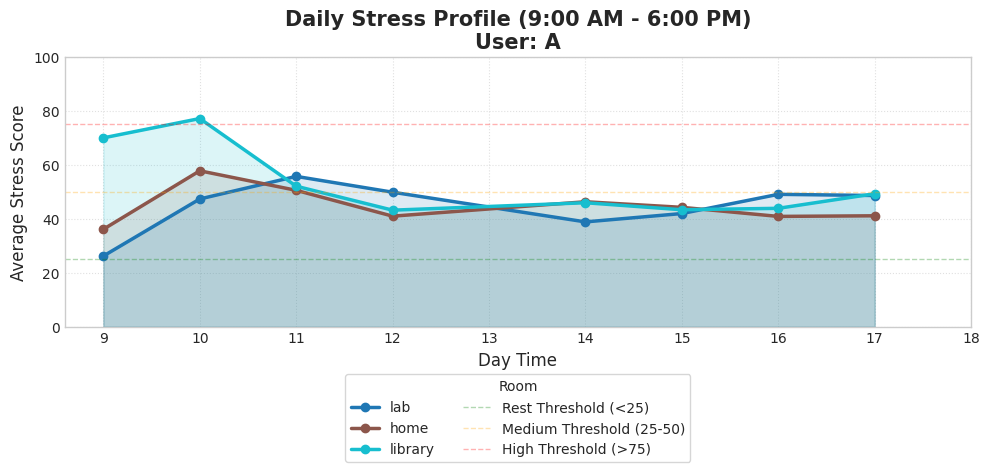

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- PREPARAZIONE DATI ---
# Assicuriamoci che i timestamp siano datetime
df_labeled['timestamp_local'] = pd.to_datetime(df_labeled['timestamp_local'])

# Filtriamo per l'utente target
user_df = df_labeled[df_labeled['garmin_id'] == target_user].copy()

# Filtro fascia oraria 9-18
user_df = user_df[(user_df['timestamp_local'].dt.hour >= 9) & (user_df['timestamp_local'].dt.hour < 18)].copy()

if user_df.empty:
    print("Nessun dato tra le 9 e le 18 per l'utente selezionato.")
else:
    # 1. ESTRAZIONE DELL'ORA (Solo il numero intero 0-23, senza data)
    user_df['hour_int'] = user_df['timestamp_local'].dt.hour

    # 2. SELEZIONE STANZE TOP
    top_rooms = user_df['room'].value_counts().head(4).index.tolist()
    
    # 3. AGGREGAZIONE
    # Calcoliamo la media dello stress per ogni ora del giorno in ogni stanza
    hourly_room = (
        user_df[user_df['room'].isin(top_rooms)]
        .groupby(['hour_int', 'room'])['stress_score']
        .mean()
        .reset_index()
    )

    # --- PLOTTING ---
    plt.figure(figsize=(10, 5))
    
    # Definiamo colori distinti per le stanze per chiarezza
    colors = plt.cm.tab10(np.linspace(0, 1, len(top_rooms)))

    for i, room in enumerate(top_rooms):
        room_data = hourly_room[hourly_room['room'] == room].sort_values('hour_int')
        
        if room_data.empty:
            continue
            
        # Plot della linea media
        plt.plot(
            room_data['hour_int'], 
            room_data['stress_score'], 
            marker='o', 
            linewidth=2.5, 
            label=room,
            color=colors[i]
        )
        
        # Area colorata: Invece di riempire fino a 0 (che sporca il grafico),
        # riempiamo leggermente sotto la curva per dare "peso" visivo ma mantenendo la leggibilità
        plt.fill_between(
            room_data['hour_int'], 
            room_data['stress_score'], 
            alpha=0.15, 
            color=colors[i]
        )

    # --- FORMATTAZIONE ESTETICA ---
    plt.title(f"Daily Stress Profile (9:00 AM - 6:00 PM)\nUser: A", fontsize=15, fontweight='bold')
    plt.xlabel("Day Time", fontsize=12)
    plt.ylabel("Average Stress Score", fontsize=12)
    
    # Impostiamo l'asse X per mostrare solo le ore intere
    plt.xticks(range(9, 19))
    
    # Limiti asse Y coerenti (0-100 per lo stress Garmin)
    plt.ylim(0, 100)
    
    # Aggiungiamo fasce di riferimento (opzionale, ma utile per il contesto)
    plt.axhline(y=25, color='green', linestyle='--', alpha=0.3, linewidth=1, label='Rest Threshold (<25)')
    plt.axhline(y=50, color='orange', linestyle='--', alpha=0.3, linewidth=1, label='Medium Threshold (25-50)')
    plt.axhline(y=75, color='red', linestyle='--', alpha=0.3, linewidth=1, label='High Threshold (>75)')

    plt.grid(True, axis='both', linestyle=':', alpha=0.6)
    plt.legend(title="Room", bbox_to_anchor=(0.5, -0.15), loc='upper center', frameon=True, ncol=2)
    
    plt.tight_layout()
    plt.show()

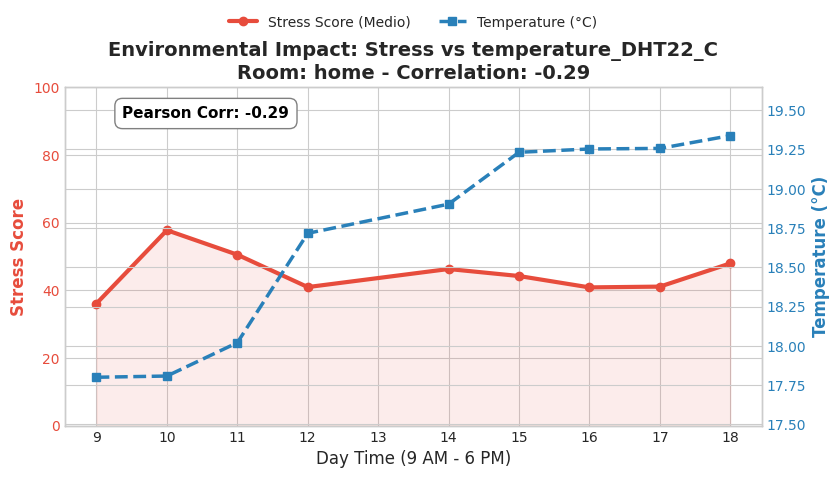

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# --- CONFIGURAZIONE ---
# Scegli la stanza che vuoi analizzare (es. quella dove lo stress è più alto)
target_room_analysis = 'home'  # Cambia con 'Cucina', 'Camera', ecc.
# Scegli la feature che vuoi confrontare
target_feature = 'temperature_DHT22_C'        # Opzioni: 'hr', 'temperature_DHT22_C', 'CO2_ppm', 'TVOC_ppb'
feature_label = 'Temperature (°C)' # Etichetta per il grafico

# --- PREPARAZIONE DATI ---
# Filtri base (User + Orario 9-18 + Stanza Specifica)
analysis_df = df_labeled[
    (df_labeled['garmin_id'] == target_user) & 
    (df_labeled['room'] == target_room_analysis) &
    (df_labeled['timestamp_local'].dt.hour >= 9) & 
    (df_labeled['timestamp_local'].dt.hour <= 18)
].copy()

if analysis_df.empty:
    print(f"Nessun dato per {target_room_analysis} nella fascia oraria indicata.")
else:
    # Estrazione ora
    analysis_df['hour_int'] = analysis_df['timestamp_local'].dt.hour

    # Aggregazione: Calcoliamo la media sia dello STRESS che della FEATURE
    hourly_analysis = (
        analysis_df.groupby('hour_int')[[ 'stress_score', target_feature ]]
        .mean()
        .reset_index()
    )

    # --- CALCOLO CORRELAZIONE ---
    correlation = hourly_analysis['stress_score'].corr(hourly_analysis[target_feature])
    corr_text = f"Correlation: {correlation:.2f}"
    
    # Colore correlazione (Verde se alta positiva, Rosso se inversa, Grigia se nulla)
    if correlation > 0.5: corr_color = 'green' # Feature sale -> Stress sale
    elif correlation < -0.5: corr_color = 'red' # Feature sale -> Stress scende
    else: corr_color = 'gray'

    # --- PLOTTING ---
    fig, ax1 = plt.subplots(figsize=(8.5, 5))

    # 1. Plot Stress (Asse Y Sinistro - Solido)
    color_stress = '#e74c3c' # Rosso
    ax1.plot(hourly_analysis['hour_int'], hourly_analysis['stress_score'], 
             color=color_stress, marker='o', linewidth=3, label='Stress Score (Medio)')
    ax1.fill_between(hourly_analysis['hour_int'], hourly_analysis['stress_score'], 
                     color=color_stress, alpha=0.1)
    
    ax1.set_xlabel('Day Time (9 AM - 6 PM)', fontsize=12)
    ax1.set_ylabel('Stress Score', fontsize=12, color=color_stress, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_stress)
    ax1.set_ylim(0, 100)
    ax1.set_xticks(range(9, 19))

    # 2. Plot Feature Ambientale (Asse Y Destro - Tratteggiato)
    ax2 = ax1.twinx()  # Crea un secondo asse Y che condivide lo stesso asse X
    
    color_feature = '#2980b9' # Blu
    ax2.plot(hourly_analysis['hour_int'], hourly_analysis[target_feature], 
             color=color_feature, marker='s', linestyle='--', linewidth=2.5, label=feature_label)
    
    ax2.set_ylabel(feature_label, fontsize=12, color=color_feature, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_feature)
    
    # Impostiamo i limiti della feature per lasciare un po' di "respiro" al grafico
    f_min, f_max = hourly_analysis[target_feature].min(), hourly_analysis[target_feature].max()
    margin = (f_max - f_min) * 0.2
    ax2.set_ylim(f_min - margin, f_max + margin)

    # --- FORMATTAZIONE FINALE ---
    plt.title(f"Environmental Impact: Stress vs {target_feature}\nRoom: {target_room_analysis} - {corr_text}", 
              fontsize=14, fontweight='bold')
    
    # Aggiungiamo un box con la correlazione nel grafico
    plt.figtext(0.15, 0.73, f"Pearson Corr: {correlation:.2f}", 
                bbox=dict(facecolor='white', edgecolor=corr_color, boxstyle='round,pad=0.5'),
                fontsize=11, fontweight='bold', color='black')

    # Uniamo le legende
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)

    plt.grid(True, axis='x', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()